<a href="https://colab.research.google.com/github/DylanMolinaArroyo/deep-learning-fundamentals-project/blob/main/Deep_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🫁 Module 1 — Chest X-Ray Classification and Segmentation**

---

## **Module Description**

This project develops a computer vision system based on modern **Deep Learning** techniques applied to AI-assisted medical diagnosis.

The system addresses two main tasks:

1. **Multi-class classification** of chest X-rays to identify whether a patient presents: *Normal*, *Pneumonia*, *COVID-19*, or *Tuberculosis*, using Transfer Learning with **ResNet-50** and **DenseNet-121**.

2. **Lung segmentation** using a **U-Net** architecture trained on the Montgomery and Shenzhen datasets, to delineate the lung region in X-ray images and extract regions of interest prior to classification.

The medical context is highly relevant: early diagnosis of respiratory diseases such as COVID-19 and Tuberculosis is critical to reducing transmission and improving patient outcomes. An AI system capable of assisting radiologists can have a direct impact in regions with a shortage of specialists.

---

> **Note:** This notebook requires GPU. In Google Colab go to `Runtime → Change runtime type → GPU (T4)`.

---
## Section 1 — Install Dependencies

In [1]:
!pip install -q kaggle segmentation-models-pytorch albumentations torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 35.3 MB/s eta 0:00:00


---
## Section 2 — Dataset Download

Three public datasets are used, all available on Kaggle:

---

### Dataset 1 — Chest X-Ray: Pneumonia, COVID-19, Tuberculosis
🔗 **Link:** [kaggle.com/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis](https://www.kaggle.com/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis)

**Description:** Dataset of chest X-rays labeled into 4 classes: *Normal*, *Pneumonia*, *COVID-19*, and *Tuberculosis*. Images come from multiple clinical sources and are organized into class folders. This is the main dataset of the project, used to train and compare the ResNet-50 and DenseNet-121 classification models.

| Attribute | Detail |
|---|---|
| Classes | Normal, Pneumonia, COVID-19, Tuberculosis |
| Format | JPEG / PNG |
| Minimum required | ≥ 200 images ✅ |
| Task | Multi-class classification |

---

### Dataset 2 — Montgomery County Tuberculosis Chest X-Rays
🔗 **Link:** [kaggle.com/datasets/raddar/tuberculosis-chest-xrays-montgomery](https://www.kaggle.com/datasets/raddar/tuberculosis-chest-xrays-montgomery)

**Description:** Dataset created by the National Library of Medicine (NIH) in collaboration with the Montgomery County Department of Health and Human Services, Maryland, USA. Contains 138 PA chest X-rays (80 normal, 58 with tuberculosis) with **manually annotated segmentation masks** for left and right lungs included. It is the reference dataset for training U-Net on lung segmentation.

| Attribute | Detail |
|---|---|
| Images | 138 PA chest X-rays |
| Classes | Normal (80), Tuberculosis (58) |
| Masks | Left and right lung (manual annotation) |
| Format | High-resolution PNG |
| Task | Lung segmentation |

---

### Dataset 3 — Shenzhen Hospital Tuberculosis Chest X-Rays
🔗 **Images link:** [kaggle.com/datasets/raddar/tuberculosis-chest-xrays-shenzhen](https://www.kaggle.com/datasets/raddar/tuberculosis-chest-xrays-shenzhen)  
🔗 **Masks link:** [kaggle.com/datasets/yoctoman/shcxr-lung-mask](https://www.kaggle.com/datasets/yoctoman/shcxr-lung-mask)

**Description:** Dataset from Shenzhen No. 3 People's Hospital, China, collected by the NIH. Contains 662 chest X-rays (340 normal, 275 with tuberculosis) captured using Philips DR Digital Diagnose systems during outpatient visits. Combined with the Montgomery dataset to expand the training set for the U-Net segmentation model.

| Attribute | Detail |
|---|---|
| Images | 662 chest X-rays |
| Classes | Normal (340), Tuberculosis (275) |
| Masks | Available separately |
| Format | PNG |
| Task | Lung segmentation (supplementary) |

## Section 3 — Connect to Google Drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Section 4 — Datasets Setup




In [6]:
import os
import zipfile
import kagglehub
import shutil

# --- Paths Configuration ---
DRIVE_MONTGOMERY_ZIP = '/content/drive/MyDrive/Proyecto-2-IA-2026/Montgomery.zip'
DRIVE_SHENZHEN_IMAGES_ZIP = '/content/drive/MyDrive/Proyecto-2-IA-2026/Shenzhen.zip'

# Destination paths for extracted datasets
DEST_MONTGOMERY = '/content/data/'
DEST_SHENZHEN_IMAGES = '/content/data/'
DEST_CLASSIFICATION = '/content/data/Chest-XRay'

# --- Helper function for dataset processing ---
def process_dataset(
    name,
    destination,
    is_kaggle,
    kaggle_dataset_id=None,
    drive_zip_path=None,
    extracted_content_check=None
):
    print(f"\nAttempting to load {name} dataset...")
    os.makedirs(destination, exist_ok=True)

    if extracted_content_check and os.path.exists(os.path.join(destination, extracted_content_check)):
        print(f"  ✅ {name} dataset already present.")
        return

    if is_kaggle:
        print(f"  ⬇️  {name} dataset not found or incomplete. Downloading from Kaggle...")
        try:
            kaggle_cache_path = kagglehub.dataset_download(kaggle_dataset_id)
            print(f"  ✅ Dataset downloaded to Kaggle cache: {kaggle_cache_path}")

            if os.path.exists(destination):
                if extracted_content_check and not os.path.exists(os.path.join(destination, extracted_content_check)):
                    print(f"  ℹ️  Clearing partial/old contents of '{destination}'.")
                    for item in os.listdir(destination):
                        item_path = os.path.join(destination, item)
                        shutil.rmtree(item_path) if os.path.isdir(item_path) else os.remove(item_path)

            for item in os.listdir(kaggle_cache_path):
                s = os.path.join(kaggle_cache_path, item)
                d = os.path.join(destination, item)
                if os.path.isdir(s):
                    shutil.copytree(s, d, dirs_exist_ok=True)
                else:
                    shutil.copy2(s, d)
            print(f"  ✅ {name} dataset copied to: {destination}")

        except Exception as e:
            print(f"  ❌ Error downloading/copying {name} dataset: {e}")
            print("  Please ensure Kaggle API is configured correctly or try re-running.")

    elif drive_zip_path:
        if os.path.exists(drive_zip_path):
            print(f"  Found '{os.path.basename(drive_zip_path)}'. Unzipping to '{destination}'...")
            try:
                with zipfile.ZipFile(drive_zip_path, 'r') as zip_ref:
                    zip_ref.extractall(destination)
                print(f"  ✅ {name} dataset extracted successfully.")
            except zipfile.BadZipFile:
                print(f"  ❌ Error: '{drive_zip_path}' is a corrupted zip file. Please check.")
            except Exception as e:
                print(f"  ❌ Error unzipping '{drive_zip_path}': {e}")
        else:
            print(f"  ❌ Error: '{drive_zip_path}' not found. Ensure your Google Drive is mounted and the file exists.")

# --- Process Datasets ---
process_dataset(
    name="Classification",
    destination=DEST_CLASSIFICATION,
    is_kaggle=True,
    kaggle_dataset_id="jtiptj/chest-xray-pneumoniacovid19tuberculosis",
    extracted_content_check='train'
)

process_dataset(
    name="Montgomery",
    destination=DEST_MONTGOMERY,
    is_kaggle=False,
    drive_zip_path=DRIVE_MONTGOMERY_ZIP,
    extracted_content_check='MontgomeryCountyCXR'
)

process_dataset(
    name="Shenzhen Images",
    destination=DEST_SHENZHEN_IMAGES,
    is_kaggle=False,
    drive_zip_path=DRIVE_SHENZHEN_IMAGES_ZIP,
    extracted_content_check='CHNCXR_png'
)

print("\nDataset processing complete.")


Attempting to load Classification dataset...
  ✅ Classification dataset already present.

Attempting to load Montgomery dataset...
  Found 'Montgomery.zip'. Unzipping to '/content/data/'...
  ✅ Montgomery dataset extracted successfully.

Attempting to load Shenzhen Images dataset...
  Found 'Shenzhen.zip'. Unzipping to '/content/data/'...
  ✅ Shenzhen Images dataset extracted successfully.

Dataset processing complete.


---
## Section 5 — File Structure Verification

In [5]:
import os

def explore_directory(path, level=0, max_level=2):
    """Displays the folder structure up to max_level levels deep, showing file and directory counts."""
    if level > max_level:
        return
    try:
        items = os.listdir(path)
        files = [f for f in items if os.path.isfile(os.path.join(path, f))]
        dirs = [d for d in items if os.path.isdir(os.path.join(path, d))]

        indent = "    " * level
        print(f"{indent}  Total files: {len(files)}")
        print(f"{indent}  Total subdirectories: {len(dirs)}")

        for item in sorted(dirs): # Only recursively explore subdirectories
            full_path = os.path.join(path, item)
            prefix = "    " * level + "📁 "
            print(f"{prefix}{item}")
            explore_directory(full_path, level + 1, max_level)

    except PermissionError:
        print(f"{indent}  ❌ Permission denied to access: {path}")
    except FileNotFoundError:
        print(f"{indent}  ❌ Directory not found: {path}")

datasets_info = {
    "Classification (main Kaggle dataset)": {
        "path": "/content/data/Chest-XRay",
    },
    "Montgomery": {
        "path": "/content/data/Montgomery",
    },
    "Shenzhen Images": {
        "path": "/content/data/Shenzhen",
    },
}

# Only view each dataset's local files
for name, info in datasets_info.items():
    print(f"\n{'='*50}")
    print(f"📂 {name}")
    print('='*50)
    target_path = info["path"]

    if os.path.exists(target_path):
        if os.listdir(target_path):
            print(f"  ✅ Directory found and not empty: {target_path}")
            # Explore the directory structure with counts
            explore_directory(target_path)
        else:
            print(f"  ⚠️  Directory found but empty: {target_path}")
    else:
        print(f"  ❌ Directory not found: {target_path}")


📂 Classification (main Kaggle dataset)
  ✅ Directory found and not empty: /content/data/Chest-XRay
  Total files: 0
  Total subdirectories: 3
📁 test
      Total files: 0
      Total subdirectories: 4
    📁 COVID19
          Total files: 106
          Total subdirectories: 0
    📁 NORMAL
          Total files: 234
          Total subdirectories: 0
    📁 PNEUMONIA
          Total files: 390
          Total subdirectories: 0
    📁 TURBERCULOSIS
          Total files: 41
          Total subdirectories: 0
📁 train
      Total files: 0
      Total subdirectories: 4
    📁 COVID19
          Total files: 460
          Total subdirectories: 0
    📁 NORMAL
          Total files: 1341
          Total subdirectories: 0
    📁 PNEUMONIA
          Total files: 3875
          Total subdirectories: 0
    📁 TURBERCULOSIS
          Total files: 650
          Total subdirectories: 0
📁 val
      Total files: 0
      Total subdirectories: 4
    📁 COVID19
          Total files: 10
          Total subdirectori

---
## 📥 Section 6 — Library Imports and Global Variables

All required libraries are imported and the **global variables** of the project are defined below.

### 📌 Global Variables Description

| Variable | Type | Description |
|---|---|---|
| `SEED` | `int` | Random seed for reproducibility across all random operations (data splits, weight initialization, augmentation) |
| `IMG_SIZE` | `tuple` | (height, width) dimensions to which all images are resized before being fed into the model |
| `BATCH_SIZE` | `int` | Number of images processed in parallel per training step. Higher values require more RAM/GPU memory |
| `EPOCHS` | `int` | Number of full passes through the training dataset |
| `LEARNING_RATE` | `float` | Optimizer learning rate. Controls how much model weights are adjusted at each step |
| `NUM_CLASSES` | `int` | Number of output classes for the classification model (Normal, Pneumonia, COVID-19, TB) |
| `TRAIN_SPLIT` | `float` | Proportion of data used for training (e.g. 0.7 = 70%) |
| `VAL_SPLIT` | `float` | Proportion of data used for validation during training |
| `TEST_SPLIT` | `float` | Proportion of data held out for final model evaluation |
| `DEVICE` | `str` | Compute device: `'cuda'` if a GPU is available, `'cpu'` otherwise |
| `DIR_CLASSIFICATION` | `str` | Root path of the classification dataset (Pneumonia/COVID-19/TB) |
| `DIR_MONTGOMERY` | `str` | Root path of the Montgomery dataset (images + masks) |
| `DIR_SHENZHEN` | `str` | Root path of the Shenzhen dataset (X-ray images) |
| `DIR_SHENZHEN_MASKS` | `str` | Root path of the Shenzhen lung segmentation masks |
| `CLASS_NAMES` | `list` | List of class names in the order predicted by the classification model |
| `MEAN_NORM` | `list` | Per-channel RGB mean values used for normalization (ImageNet standard) |
| `STD_NORM` | `list` | Per-channel RGB standard deviation values for normalization (ImageNet standard) |

In [8]:
# ── Standard library ──────────────────────────────────────────
import os
import random
import warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ─────────────────────────────────────────
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Image processing ──────────────────────────────────────────
from PIL import Image
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── PyTorch ───────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import torchmetrics

# ── Segmentation models ───────────────────────────────────────
import segmentation_models_pytorch as smp

print("✅ Libraries imported successfully.")

# ═════════════════════════════════════════════════════════════
# GLOBAL VARIABLES
# ═════════════════════════════════════════════════════════════

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
# Fixed seed to ensure reproducible results across
# data splits, weight initialization, and random operations

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Image size ────────────────────────────────────────────────
IMG_SIZE = (224, 224)
# Standard input size for both ResNet-50 and DenseNet-121
# Both models were pretrained on 224×224 ImageNet images

# ── Training hyperparameters ──────────────────────────────────
BATCH_SIZE = 32
# Number of images per batch. Reduce to 16 if GPU runs out of memory

EPOCHS = 25
# Number of training epochs
# Recommended to use EarlyStopping to prevent overfitting

LEARNING_RATE = 1e-4
# Initial learning rate. A low value is recommended for fine-tuning
# pretrained models (Transfer Learning)

# ── Classification ────────────────────────────────────────────
NUM_CLASSES = 4
# Output classes for the classification model:
# 0: Normal | 1: Pneumonia | 2: COVID-19 | 3: Tuberculosis

CLASS_NAMES = ['Normal', 'Pneumonia', 'COVID-19', 'Tuberculosis']
# List of class names in the order the model predicts them

# ── Data splits ───────────────────────────────────────────────
TRAIN_SPLIT = 0.70
# 70% of data used for training

VAL_SPLIT = 0.15
# 15% of data used for validation during training

TEST_SPLIT = 0.15
# 15% of data reserved for final evaluation (not touched until the end)

# ── Normalization ─────────────────────────────────────────────
MEAN_NORM = [0.485, 0.456, 0.406]
# Per-channel RGB mean from ImageNet pretraining
# Applied to align our data distribution with the model's expectations

STD_NORM = [0.229, 0.224, 0.225]
# Per-channel RGB std from ImageNet pretraining
# Normalization formula: pixel_norm = (pixel - mean) / std

# ── Compute device ────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# Automatic selection: uses GPU (CUDA) if available, otherwise CPU
# In Google Colab with T4 GPU this should display 'cuda'

# ── Dataset paths ─────────────────────────────────────────────
DIR_CLASSIFICATION = Path('/content/data/Chest-XRay')
# Root path of the main dataset: Pneumonia / COVID-19 / TB / Normal

DIR_MONTGOMERY = Path('/content/data/Montgomery')
# Root path of the Montgomery dataset with X-rays and segmentation masks

DIR_SHENZHEN = Path('/content/data/Shenzhen')
# Root path of the Shenzhen X-ray images

DIR_SHENZHEN_MASKS = Path('/content/data/Shenzhen/mask')
# Root path of the Shenzhen lung segmentation masks

# ── Configuration summary ─────────────────────────────────────
print(f"""
{'='*45}
  PROJECT CONFIGURATION
{'='*45}
  Device           : {DEVICE.upper()}
  Image size       : {IMG_SIZE}
  Batch size       : {BATCH_SIZE}
  Epochs           : {EPOCHS}
  Learning rate    : {LEARNING_RATE}
  Classes          : {CLASS_NAMES}
  Train/Val/Test   : {TRAIN_SPLIT}/{VAL_SPLIT}/{TEST_SPLIT}
  Seed             : {SEED}
{'='*45}
""")

✅ Libraries imported successfully.

  PROJECT CONFIGURATION
  Device           : CUDA
  Image size       : (224, 224)
  Batch size       : 32
  Epochs           : 25
  Learning rate    : 0.0001
  Classes          : ['Normal', 'Pneumonia', 'COVID-19', 'Tuberculosis']
  Train/Val/Test   : 0.7/0.15/0.15
  Seed             : 42



---
## 🔎 Section 7 — Exploratory Data Analysis (EDA)

Before training any model, it is important to understand the data distribution: how many images exist per class, whether class imbalance is present, and what the images look like visually.

📊 Image Distribution — Classification Dataset
------------------------------------------
  test           :   771 images (10.8%)
  train          :  6326 images (88.7%)
  val            :    38 images (0.5%)
  TOTAL          :  7135 images


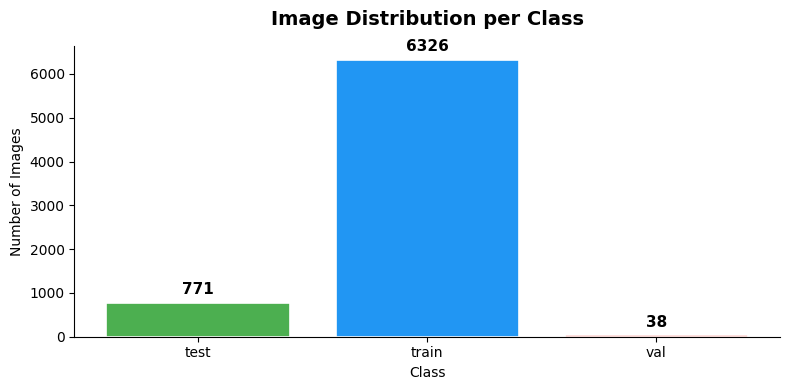

In [9]:
# ── Image count per class (Classification Dataset) ────────────

def count_images_per_class(root_path):
    """
    Walks the subdirectories of root_path and counts images per class.
    Assumes each subdirectory represents one class.

    Args:
        root_path (Path): Root directory containing one subfolder per class.

    Returns:
        dict: {class_name: image_count}
    """
    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
    counts = {}
    for folder in sorted(root_path.iterdir()):
        if folder.is_dir():
            images = [f for f in folder.rglob('*') if f.suffix.lower() in valid_extensions]
            counts[folder.name] = len(images)
    return counts


# Count images in the classification dataset
class_counts = count_images_per_class(DIR_CLASSIFICATION)

print("📊 Image Distribution — Classification Dataset")
print("-" * 42)
total = sum(class_counts.values())
for cls, count in class_counts.items():
    pct = count / total * 100
    print(f"  {cls:<15}: {count:>5} images ({pct:.1f}%)")
print(f"  {'TOTAL':<15}: {total:>5} images")

# Distribution bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4CAF50', '#2196F3', '#F44336', '#FF9800']
bars = ax.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, padding=4, fontsize=11, fontweight='bold')
ax.set_title('Image Distribution per Class', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Images')
ax.set_xlabel('Class')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

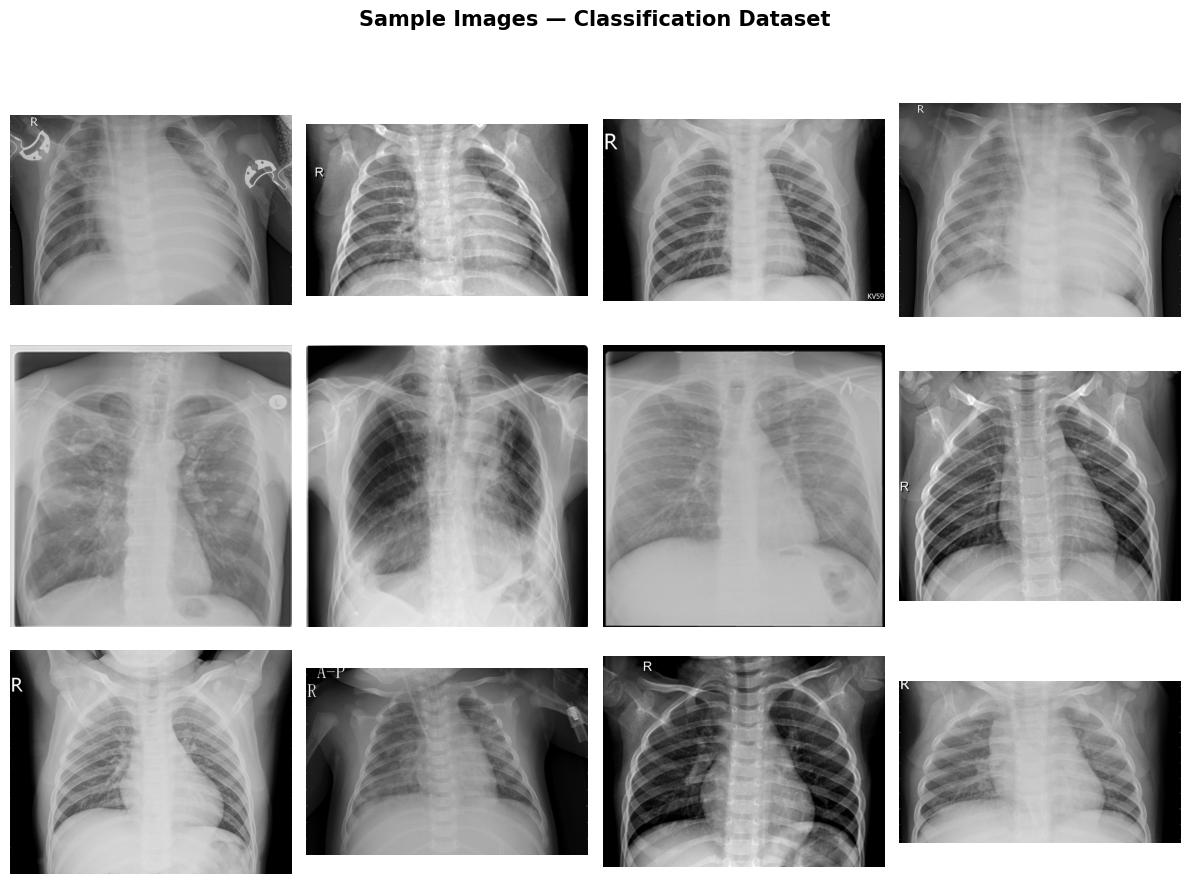

In [10]:
# ── Sample visualization per class ────────────────────────────

def show_samples(root_path, n_samples=4):
    """
    Displays n_samples random images from each class.

    Args:
        root_path (Path): Root directory containing one subfolder per class.
        n_samples (int): Number of images to display per class.
    """
    valid_extensions = {'.jpg', '.jpeg', '.png'}
    classes = [c for c in sorted(root_path.iterdir()) if c.is_dir()]

    fig, axes = plt.subplots(len(classes), n_samples, figsize=(n_samples * 3, len(classes) * 3))
    fig.suptitle('Sample Images — Classification Dataset', fontsize=15, fontweight='bold', y=1.01)

    for i, folder in enumerate(classes):
        images = [f for f in folder.rglob('*') if f.suffix.lower() in valid_extensions]
        samples = random.sample(images, min(n_samples, len(images)))
        for j, img_path in enumerate(samples):
            img = Image.open(img_path).convert('RGB')
            axes[i][j].imshow(img, cmap='gray')
            axes[i][j].axis('off')
            if j == 0:
                axes[i][j].set_ylabel(folder.name, fontsize=12, fontweight='bold', labelpad=10)
                axes[i][j].yaxis.set_visible(True)
                axes[i][j].tick_params(left=False, labelleft=True)
    plt.tight_layout()
    plt.show()

show_samples(DIR_CLASSIFICATION, n_samples=4)

---
## Section 8 — Preprocessing and Data Augmentation

### 📌 Transformation variables description

| Variable | Description |
|---|---|
| `transform_train` | Transformation pipeline for the training set. Includes augmentation (flips, rotations, brightness) to increase data variability and reduce overfitting |
| `transform_val_test` | Transformation pipeline for validation and test sets. Only resizes and normalizes — no augmentation, to evaluate on clean data |
| `HorizontalFlip` | Random horizontal flip. Valid for chest X-rays (the mirrored image remains diagnostically meaningful) |
| `RandomBrightnessContrast` | Random brightness and contrast variation. Simulates differences in radiological equipment exposure |
| `Rotate` | Slight random rotation (±10°). Compensates for small differences in patient positioning |
| `Normalize` | Per-channel normalization using ImageNet mean and std values |
| `ToTensorV2` | Converts NumPy arrays to PyTorch tensors in `(C, H, W)` format |

In [13]:
# ── Training transforms (with augmentation) ───────────────────
transform_train = A.Compose([
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),          # Resize to 224×224
    A.HorizontalFlip(p=0.5),                     # Horizontal flip with 50% probability
    A.Rotate(limit=10, p=0.4),                   # Slight rotation (±10°)
    A.RandomBrightnessContrast(p=0.3),           # Brightness/contrast variation
    A.GaussNoise(p=0.2),                         # Mild Gaussian noise
    A.Normalize(mean=MEAN_NORM, std=STD_NORM),   # ImageNet normalization
    ToTensorV2()                                  # Convert to PyTorch tensor
])

# ── Validation and test transforms (no augmentation) ──────────
transform_val_test = A.Compose([
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.Normalize(mean=MEAN_NORM, std=STD_NORM),
    ToTensorV2()
])

print("✅ Transformation pipelines defined.")
print(f"   Training  : {len(transform_train.transforms)} transforms (with augmentation)")
print(f"   Val / Test: {len(transform_val_test.transforms)} transforms (normalization only)")

✅ Transformation pipelines defined.
   Training  : 7 transforms (with augmentation)
   Val / Test: 3 transforms (normalization only)


---
## 🧠 Section 9 — Transfer Learning Models

Two models pretrained on ImageNet will be adapted for 4-class classification via **fine-tuning**:

| Model | Architecture | Approx. Parameters | Advantage |
|---|---|---|---|
| **ResNet-50** | Residual Networks with skip connections | ~25M | Robust, solid baseline, widely validated on medical images |
| **DenseNet-121** | Dense connections between all layers | ~8M | Efficient feature reuse; standard in radiology (CheXNet) |

### Fine-tuning strategy
1. Load ImageNet pretrained weights
2. Freeze the backbone (convolutional layers)
3. Replace the final classifier with a 4-class head
4. Phase 1: train only the classifier head
5. Phase 2 (optional): unfreeze the last backbone layers and retrain with a lower LR

In [12]:
def build_resnet50(num_classes, freeze_backbone=True):
    """
    Builds a pretrained ResNet-50 adapted for multi-class classification.

    Args:
        num_classes (int): Number of output classes.
        freeze_backbone (bool): If True, freezes all layers except the classifier head.

    Returns:
        model (nn.Module): Model ready for training.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the final fully-connected layer
    # model.fc is the original 1000-class ImageNet classifier
    in_features = model.fc.in_features  # 2048 for ResNet-50
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),              # Regularization: randomly drops 40% of neurons
        nn.Linear(in_features, 512),    # Intermediate hidden layer
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)     # Output: 4 classes
    )
    return model.to(DEVICE)


def build_densenet121(num_classes, freeze_backbone=True):
    """
    Builds a pretrained DenseNet-121 adapted for multi-class classification.
    DenseNet-121 is the base architecture of CheXNet, the reference model
    for chest X-ray pathology classification.

    Args:
        num_classes (int): Number of output classes.
        freeze_backbone (bool): If True, freezes all layers except the classifier head.

    Returns:
        model (nn.Module): Model ready for training.
    """
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace DenseNet's classifier head
    # model.classifier is the original 1000-class output layer
    in_features = model.classifier.in_features  # 1024 for DenseNet-121
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    return model.to(DEVICE)


# Instantiate both models
model_resnet   = build_resnet50(NUM_CLASSES)
model_densenet = build_densenet121(NUM_CLASSES)

# Count trainable parameters
def count_parameters(model):
    total      = sum(p.numel() for p in model.parameters())
    trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

t_r, e_r = count_parameters(model_resnet)
t_d, e_d = count_parameters(model_densenet)

print(f"{'Model':<15} {'Total params':>15} {'Trainable':>15}")
print("-" * 47)
print(f"{'ResNet-50':<15} {t_r:>15,} {e_r:>15,}")
print(f"{'DenseNet-121':<15} {t_d:>15,} {e_d:>15,}")
print(f"\n✅ Models created on device: {DEVICE.upper()}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 163MB/s]


Model              Total params       Trainable
-----------------------------------------------
ResNet-50            24,559,172       1,051,140
DenseNet-121          7,480,708         526,852

✅ Models created on device: CUDA


---
## 🚀 Section 10 — Next Steps (Computer Vision)

The following sections will complete the full Computer Vision pipeline:

```
Section 10 │ Dataset Classes (PyTorch Dataset + DataLoaders)
Section 11 │ ResNet-50 Training
Section 12 │ DenseNet-121 Training
Section 13 │ Model Evaluation and Comparison
           │   → Accuracy, Precision, Recall, F1-Score
           │   → Confusion Matrix
           │   → Grad-CAM (activation map visualization)
Section 14 │ U-Net — Lung Segmentation (Montgomery + Shenzhen)
           │   → IoU (Intersection over Union)
           │   → Dice Score
Section 15 │ Computer Vision Results Analysis and Conclusions
```

---
> 💡 **Tip:** Save model checkpoints at the end of each epoch using `torch.save(model.state_dict(), 'checkpoint.pt')` to avoid losing training progress if the Colab session expires.

# **🎙️ Module 2 — Automatic Speech Recognition (ASR) with CTC**

---

## **Module Description**

This module develops an **Automatic Speech Recognition (ASR)** system capable of converting spoken language into text using Deep Learning techniques based on **Connectionist Temporal Classification (CTC)**.

The system processes raw audio recordings and generates textual transcriptions **without requiring frame-level alignment** between the audio signal and the text labels — a key advantage of CTC over traditional approaches.

### What the system will be able to do:
- Recognize spoken commands from audio recordings
- Convert continuous speech into readable text
- Perform automatic transcription of labeled audio samples

### Why CTC?
Traditional sequence-to-sequence models require knowing exactly which audio frame corresponds to which character. CTC eliminates this requirement by allowing the model to output a probability distribution over all possible alignments and collapsing repeated characters and blank tokens — making it ideal for speech where phoneme boundaries are unclear.

---

> ⚡ **Note:** Audio processing is CPU-intensive for feature extraction (MFCC) but training benefits greatly from GPU. Keep the T4 GPU runtime active.

---
## 📦 Section 10 — Install ASR Dependencies

The following libraries are required for audio processing, feature extraction, and ASR model training:

| Library | Purpose |
|---|---|
| `librosa` | Audio loading, MFCC and Mel Spectrogram extraction |
| `torchaudio` | PyTorch-native audio processing and CTC loss |
| `soundfile` | Reading and writing audio files (WAV, FLAC) |
| `jiwer` | Computing Word Error Rate (WER) and Character Error Rate (CER) |
| `datasets` | HuggingFace datasets library for easy audio dataset loading |
| `transformers` | Optional: pretrained Wav2Vec2 or Whisper models for comparison |

In [ ]:
# Install ASR-specific libraries
# TODO: Run this cell before starting the ASR module
!pip install -q librosa soundfile jiwer datasets transformers torchaudio

---
## 🗂️ Section 11 — ASR Dataset

### Selected Dataset — Google Speech Commands
🔗 **Link:** [kaggle.com/datasets/neehakurelli/google-speech-commands](https://www.kaggle.com/datasets/neehakurelli/google-speech-commands)

**Description:** The Google Speech Commands dataset is a large-scale collection of one-second audio clips of spoken English words, recorded by thousands of different speakers. Each audio sample is labeled with the spoken word (command). The dataset is widely used as a benchmark for keyword spotting and speech recognition research.

It contains commands such as: *yes*, *no*, *up*, *down*, *left*, *right*, *on*, *off*, *stop*, *go*, among others — making it ideal for building a spoken command recognition system.

| Attribute | Detail |
|---|---|
| Audio samples | 65,000+ one-second clips |
| Speakers | 1,800+ different speakers |
| Format | WAV, 16 kHz, mono |
| Labels | 30 spoken word categories |
| Minimum required | ≥ 100 labeled samples ✅ |
| Task | Spoken command recognition / Speech-to-Text |

---

**Alternative datasets (if needed):**

| Dataset | Link | Description |
|---|---|---|
| LibriSpeech (mini) | [kaggle.com/datasets/...](https://www.kaggle.com/datasets/victorletzelter/librispeech-mini) | Subset of LibriSpeech with read English speech |
| Mozilla Common Voice | [commonvoice.mozilla.org](https://commonvoice.mozilla.org/en/datasets) | Multilingual crowd-sourced speech recordings |
| TIMIT | Available via LDC | Phonemically rich speech corpus, sentence-level |

In [ ]:
# ─────────────────────────────────────────────────────────────
# ASR Dataset: Google Speech Commands
# ─────────────────────────────────────────────────────────────
# TODO: Download the ASR dataset using the Kaggle API
# Make sure Section 2 (Kaggle API setup) has been run first

# print("⬇️  Downloading ASR Dataset: Google Speech Commands...")
# !kaggle datasets download -d neehakurelli/google-speech-commands \
#     --unzip -p /content/data/speech_commands -q
# print("✅ ASR Dataset ready.")

print("ℹ️  ASR dataset download cell — uncomment when ready to use.")

---
## 📥 Section 12 — ASR Library Imports and Global Variables

### 📌 ASR Global Variables Description

| Variable | Type | Description |
|---|---|---|
| `SAMPLE_RATE` | `int` | Audio sample rate in Hz. Standard for speech models is 16,000 Hz (16 kHz) |
| `N_MFCC` | `int` | Number of Mel Frequency Cepstral Coefficients (MFCC) to extract per audio frame. Typical range: 13–40 |
| `N_MELS` | `int` | Number of Mel filterbanks used when computing Mel Spectrograms. Higher = more frequency resolution |
| `HOP_LENGTH` | `int` | Number of audio samples between successive frames during STFT. Controls temporal resolution of features |
| `N_FFT` | `int` | Size of the Fast Fourier Transform window. Determines frequency resolution of the spectrogram |
| `MAX_AUDIO_LEN` | `int` | Maximum audio duration in seconds. Clips longer than this will be truncated; shorter ones zero-padded |
| `BLANK_TOKEN` | `int` | Index of the CTC blank token in the output vocabulary. Typically set to 0 or the last index |
| `VOCAB` | `list` | Character-level vocabulary used to encode transcriptions (e.g. all lowercase letters + space + blank) |
| `VOCAB_SIZE` | `int` | Total number of tokens in the vocabulary. Determines the output dimension of the CTC model |
| `CHAR_TO_IDX` | `dict` | Mapping from character to integer index, used to encode ground truth labels for CTC training |
| `IDX_TO_CHAR` | `dict` | Inverse mapping from integer index to character, used to decode model predictions into text |
| `DIR_SPEECH` | `Path` | Root path of the speech commands audio dataset |
| `ASR_BATCH_SIZE` | `int` | Batch size for the ASR DataLoader. Audio batches are typically smaller due to variable sequence lengths |
| `ASR_EPOCHS` | `int` | Number of training epochs for the ASR model |
| `ASR_LEARNING_RATE` | `float` | Learning rate for the ASR model optimizer |

In [ ]:
# ── ASR-specific imports ───────────────────────────────────────
# TODO: Uncomment when ASR dependencies are installed

# import librosa
# import librosa.display
# import torchaudio
# import soundfile as sf
# from jiwer import wer, cer

# ═════════════════════════════════════════════════════════════
# ASR GLOBAL VARIABLES
# ═════════════════════════════════════════════════════════════

# ── Audio parameters ──────────────────────────────────────────
SAMPLE_RATE = 16000
# Standard sample rate for speech recognition models (16 kHz)
# Google Speech Commands is already recorded at 16 kHz

MAX_AUDIO_LEN = 1
# Maximum audio clip duration in seconds
# All clips in Speech Commands are exactly 1 second

# ── MFCC feature extraction ───────────────────────────────────
N_MFCC = 40
# Number of MFCC coefficients to extract per frame
# MFCCs approximate how the human ear perceives sound frequencies
# 40 coefficients provide a good balance of detail and efficiency

N_MELS = 128
# Number of Mel filterbanks for Mel Spectrogram computation
# Higher values capture more spectral detail in the frequency domain

N_FFT = 512
# FFT window size (number of samples)
# Controls frequency resolution: larger N_FFT = finer frequency bins

HOP_LENGTH = 160
# Number of samples between consecutive STFT frames
# At 16 kHz, hop_length=160 gives 10ms steps (standard for ASR)

# ── CTC vocabulary ────────────────────────────────────────────
VOCAB = ['<blank>'] + list('abcdefghijklmnopqrstuvwxyz ') + ['<unk>']
# Character-level vocabulary for CTC decoding
# <blank>: special CTC token used to separate repeated characters
# a-z: all lowercase English letters
# ' ': space character to separate words
# <unk>: unknown token for characters outside the vocabulary

VOCAB_SIZE = len(VOCAB)
# Total number of tokens — this is the output dimension of the CTC head

BLANK_TOKEN = 0
# Index of the CTC blank token in the vocabulary (must match nn.CTCLoss blank parameter)

CHAR_TO_IDX = {char: idx for idx, char in enumerate(VOCAB)}
# Dictionary mapping each character to its integer index
# Used to encode ground truth transcriptions into integer sequences for CTC loss

IDX_TO_CHAR = {idx: char for char, idx in CHAR_TO_IDX.items()}
# Inverse dictionary: maps integer indices back to characters
# Used during decoding to convert model output probabilities into readable text

# ── ASR dataset path ──────────────────────────────────────────
DIR_SPEECH = Path('/content/data/speech_commands')
# Root path of the Google Speech Commands dataset
# Each subfolder corresponds to one spoken word class

# ── ASR training parameters ───────────────────────────────────
ASR_BATCH_SIZE = 16
# Smaller batch size than CV due to variable-length audio sequences
# Audio batches require padding, which increases memory usage

ASR_EPOCHS = 30
# Number of training epochs for the ASR model

ASR_LEARNING_RATE = 3e-4
# Learning rate for the ASR model optimizer (slightly higher than CV fine-tuning)
# The ASR model is trained from scratch, not fine-tuned from pretrained weights

# ── Summary ───────────────────────────────────────────────────
print(f"""
{'='*45}
  ASR MODULE CONFIGURATION
{'='*45}
  Sample rate      : {SAMPLE_RATE} Hz
  Max audio length : {MAX_AUDIO_LEN} second(s)
  MFCC coefficients: {N_MFCC}
  Mel filterbanks  : {N_MELS}
  FFT window size  : {N_FFT}
  Hop length       : {HOP_LENGTH} samples (10 ms steps)
  Vocabulary size  : {VOCAB_SIZE} tokens
  Blank token idx  : {BLANK_TOKEN}
  Batch size       : {ASR_BATCH_SIZE}
  Epochs           : {ASR_EPOCHS}
  Learning rate    : {ASR_LEARNING_RATE}
{'='*45}
""")

---
## 🔎 Section 13 — ASR Exploratory Data Analysis (EDA)

Before building the ASR model, it is essential to understand the audio data:
- How many audio samples exist per word/command class
- What the raw waveforms look like
- What MFCC and Mel Spectrogram features look like
- Whether audio duration and sample rate are consistent across the dataset

### Key visualizations to generate:

| Visualization | Description |
|---|---|
| **Waveform plot** | Raw amplitude of the audio signal over time |
| **MFCC heatmap** | 2D representation of MFCC features (time × coefficients) |
| **Mel Spectrogram** | Log-scale frequency energy over time — the main input to the model |
| **Class distribution** | Bar chart of sample count per spoken command |
| **Duration histogram** | Distribution of audio clip lengths across the dataset |

> 📝 **TODO:** Implement EDA visualizations once the dataset is downloaded. Include at least one waveform, one MFCC plot, and one Mel Spectrogram per class sample.

In [ ]:
# ── ASR EDA ───────────────────────────────────────────────────
# TODO: Implement the following visualizations after downloading the dataset
#
# 1. Count audio samples per class
#    - Walk DIR_SPEECH subdirectories
#    - Count .wav files per folder
#    - Plot a bar chart of class distribution
#
# 2. Load and plot a sample waveform
#    - Use librosa.load(audio_path, sr=SAMPLE_RATE)
#    - Plot amplitude vs. time with librosa.display.waveshow()
#
# 3. Extract and visualize MFCC features
#    - mfcc = librosa.feature.mfcc(y=audio, sr=SAMPLE_RATE, n_mfcc=N_MFCC)
#    - Plot as a heatmap with librosa.display.specshow()
#
# 4. Extract and visualize Mel Spectrogram
#    - mel = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS)
#    - Convert to log scale: librosa.power_to_db(mel, ref=np.max)
#    - Plot with librosa.display.specshow()
#
# 5. Plot audio duration histogram
#    - Load each file and record its duration
#    - Plot a histogram to verify consistency

print("ℹ️  ASR EDA cell — implement after dataset download.")

---
## 🔄 Section 14 — Audio Preprocessing and Feature Extraction

Raw audio signals cannot be fed directly into neural networks. They must be transformed into 2D feature representations that capture the relevant acoustic information. Two main features are used in this project:

### Feature Extraction Methods

| Feature | Description | Shape |
|---|---|---|
| **MFCC** | Mel Frequency Cepstral Coefficients. Compact representation of the spectral envelope of audio. Closely models human auditory perception | `(N_MFCC, time_steps)` |
| **Mel Spectrogram** | Log-compressed energy in Mel-scaled frequency bands over time. Richer than MFCC, preferred for deep learning models | `(N_MELS, time_steps)` |

### Preprocessing steps

1. **Load audio** at a fixed sample rate (16 kHz)
2. **Normalize amplitude** to [-1, 1] range
3. **Pad or truncate** to `MAX_AUDIO_LEN` seconds
4. **Extract features** (MFCC or Mel Spectrogram)
5. **Normalize features** (zero mean, unit variance per feature)
6. **Convert to tensor** for PyTorch DataLoader

### 📌 Preprocessing variables description

| Variable | Description |
|---|---|
| `audio` | Raw waveform loaded from file as a 1D NumPy array of shape `(num_samples,)` |
| `mfcc` | MFCC feature matrix of shape `(N_MFCC, time_steps)` extracted from the audio |
| `mel_spec` | Mel Spectrogram matrix of shape `(N_MELS, time_steps)` in log scale (dB) |
| `delta_mfcc` | First-order derivative of MFCC features — captures rate of change over time |
| `delta2_mfcc` | Second-order derivative of MFCC — captures acceleration of spectral changes |
| `label_encoded` | Integer-encoded transcription: list of character indices from `CHAR_TO_IDX` |
| `input_lengths` | Tensor of feature sequence lengths per sample — required by `nn.CTCLoss` |
| `target_lengths` | Tensor of label sequence lengths per sample — required by `nn.CTCLoss` |

> 📝 **TODO:** Implement the `AudioDataset` class and `extract_features()` function.

In [ ]:
# ── Audio feature extraction ───────────────────────────────────
# TODO: Implement the following functions
#
# def extract_features(audio_path, feature_type='mfcc'):
#     """
#     Loads an audio file and extracts acoustic features.
#
#     Args:
#         audio_path (str): Path to the .wav file.
#         feature_type (str): 'mfcc' or 'mel_spectrogram'.
#
#     Returns:
#         features (np.ndarray): 2D feature array of shape (features, time_steps).
#     """
#     audio, sr = librosa.load(audio_path, sr=SAMPLE_RATE)
#
#     # Pad or truncate to MAX_AUDIO_LEN seconds
#     target_len = SAMPLE_RATE * MAX_AUDIO_LEN
#     if len(audio) < target_len:
#         audio = np.pad(audio, (0, target_len - len(audio)))
#     else:
#         audio = audio[:target_len]
#
#     if feature_type == 'mfcc':
#         features = librosa.feature.mfcc(y=audio, sr=sr,
#                                          n_mfcc=N_MFCC,
#                                          n_fft=N_FFT,
#                                          hop_length=HOP_LENGTH)
#     elif feature_type == 'mel_spectrogram':
#         mel = librosa.feature.melspectrogram(y=audio, sr=sr,
#                                               n_mels=N_MELS,
#                                               n_fft=N_FFT,
#                                               hop_length=HOP_LENGTH)
#         features = librosa.power_to_db(mel, ref=np.max)
#
#     # Normalize features: zero mean, unit variance
#     features = (features - features.mean()) / (features.std() + 1e-8)
#     return features
#
#
# class AudioDataset(Dataset):
#     """
#     PyTorch Dataset for loading audio files and their transcription labels.
#
#     Args:
#         file_paths (list): List of paths to .wav audio files.
#         labels (list): List of text transcriptions corresponding to each file.
#         feature_type (str): 'mfcc' or 'mel_spectrogram'.
#     """
#     def __init__(self, file_paths, labels, feature_type='mfcc'):
#         self.file_paths = file_paths
#         self.labels = labels
#         self.feature_type = feature_type
#
#     def __len__(self):
#         return len(self.file_paths)
#
#     def __getitem__(self, idx):
#         features = extract_features(self.file_paths[idx], self.feature_type)
#         label = [CHAR_TO_IDX.get(c, CHAR_TO_IDX['<unk>']) for c in self.labels[idx].lower()]
#         return torch.FloatTensor(features), torch.LongTensor(label)

print("ℹ️  Audio preprocessing cell — implement after dataset download.")

---
## 🧠 Section 15 — CTC Model Architecture

The ASR model follows a **CNN + RNN + CTC** architecture, which is the standard approach for end-to-end speech recognition without alignment:

```
Input Audio
     │
     ▼
Feature Extraction (MFCC / Mel Spectrogram)
     │
     ▼
CNN Encoder       ← Extracts local acoustic patterns (phoneme-like features)
     │
     ▼
Bidirectional RNN ← Models temporal dependencies across the full sequence
(GRU or LSTM)       (reads audio both forward and backward)
     │
     ▼
Linear Projection ← Maps RNN output to vocabulary size
     │
     ▼
Log Softmax       ← Probability distribution over vocabulary at each time step
     │
     ▼
CTC Decoder       ← Collapses repeated tokens and blanks → final transcription
```

### 📌 Model architecture variables description

| Variable | Description |
|---|---|
| `input_size` | Size of the input feature vector per time step — equals `N_MFCC` or `N_MELS` depending on the chosen feature |
| `hidden_size` | Number of hidden units in each RNN layer. Controls model capacity — larger = more expressive but slower |
| `num_rnn_layers` | Number of stacked Bidirectional RNN layers. Deeper networks capture higher-level temporal patterns |
| `rnn_type` | Type of recurrent unit: `'GRU'` (faster, fewer parameters) or `'LSTM'` (more expressive) |
| `dropout_rnn` | Dropout probability applied between RNN layers to reduce overfitting |
| `ctc_loss` | Instance of `nn.CTCLoss` — the loss function that trains the model without needing alignment labels |
| `log_probs` | Log-softmax output of the model with shape `(time_steps, batch_size, vocab_size)` — required by CTCLoss |
| `input_lengths` | Tensor of shape `(batch_size,)` with the number of time steps per sample in the batch |
| `target_lengths` | Tensor of shape `(batch_size,)` with the number of characters in each target transcription |

> 📝 **TODO:** Implement the `CTCModel` class using `nn.Conv1d` for the CNN encoder and `nn.GRU` or `nn.LSTM` for the RNN layers.

In [ ]:
# ── CTC Model architecture ─────────────────────────────────────
# TODO: Implement the ASR model
#
# Key components to implement:
#
# 1. CNN Encoder
#    - Use nn.Conv1d layers to extract local features from the input spectrogram
#    - Apply BatchNorm1d and ReLU activations
#    - Optionally use MaxPool1d to reduce temporal resolution
#
# 2. Bidirectional RNN
#    - Use nn.GRU or nn.LSTM with bidirectional=True
#    - Stack 2-4 layers for better sequence modeling
#    - Apply Dropout between layers
#
# 3. Output projection
#    - nn.Linear(hidden_size * 2, VOCAB_SIZE)  # *2 because bidirectional
#    - nn.LogSoftmax(dim=-1)  # Required by nn.CTCLoss
#
# 4. CTC Loss setup
#    - ctc_loss = nn.CTCLoss(blank=BLANK_TOKEN, reduction='mean', zero_infinity=True)
#    - loss = ctc_loss(log_probs, targets, input_lengths, target_lengths)
#
# Architecture hyperparameters:
hidden_size    = 256   # RNN hidden units per direction
num_rnn_layers = 3     # Number of stacked bidirectional RNN layers
rnn_type       = 'GRU' # 'GRU' or 'LSTM'
dropout_rnn    = 0.3   # Dropout between RNN layers

print("ℹ️  CTC model architecture cell — implement the CTCModel class.")
print(f"  RNN type       : {rnn_type}")
print(f"  Hidden size    : {hidden_size} (x2 bidirectional = {hidden_size*2})")
print(f"  RNN layers     : {num_rnn_layers}")
print(f"  Vocabulary size: {VOCAB_SIZE}")
print(f"  Dropout        : {dropout_rnn}")

---
## 📊 Section 16 — ASR Evaluation Metrics

Speech recognition models are evaluated using **sequence-level error metrics** that measure how different the predicted transcription is from the ground truth:

| Metric | Formula | Description |
|---|---|---|
| **WER** (Word Error Rate) | `(S + D + I) / N` | Fraction of words that are substituted (S), deleted (D), or inserted (I) relative to the total number of reference words (N). Lower is better. |
| **CER** (Character Error Rate) | `(S + D + I) / N` | Same as WER but computed at the character level. More granular — useful when word boundaries are ambiguous. |

### Interpretation
- **WER = 0.0** → perfect transcription (every word matches)
- **WER = 1.0** → every word is wrong
- **CER < WER** is typical — small character errors within words don't necessarily invalidate the full word
- State-of-the-art ASR systems achieve WER < 5% on clean speech benchmarks

### 📌 Metric variables description

| Variable | Description |
|---|---|
| `predictions` | List of decoded text strings output by the CTC model for each audio sample |
| `references` | List of ground truth transcription strings corresponding to each audio sample |
| `wer_score` | Computed Word Error Rate across the entire test set (float between 0 and 1) |
| `cer_score` | Computed Character Error Rate across the entire test set (float between 0 and 1) |

> 📝 **TODO:** Implement `decode_ctc()` to convert model log-probability outputs into text using greedy decoding (argmax) or beam search decoding.

In [ ]:
# ── ASR Evaluation ─────────────────────────────────────────────
# TODO: Implement evaluation after model training
#
# 1. CTC Greedy Decoder
#    def decode_ctc(log_probs):
#        """
#        Greedy CTC decoding: takes argmax at each time step,
#        then collapses repeated tokens and removes blank tokens.
#
#        Args:
#            log_probs (Tensor): shape (time_steps, vocab_size)
#        Returns:
#            text (str): decoded transcription
#        """
#        indices = torch.argmax(log_probs, dim=-1)  # Greedy argmax
#        # Collapse: remove consecutive duplicates
#        decoded = [idx.item() for i, idx in enumerate(indices)
#                   if i == 0 or idx != indices[i-1]]
#        # Remove blank tokens
#        decoded = [idx for idx in decoded if idx != BLANK_TOKEN]
#        return ''.join([IDX_TO_CHAR.get(i, '') for i in decoded])
#
# 2. Compute WER and CER using jiwer:
#    from jiwer import wer, cer
#    wer_score = wer(references, predictions)
#    cer_score = cer(references, predictions)
#    print(f"WER: {wer_score:.4f} ({wer_score*100:.2f}%)")
#    print(f"CER: {cer_score:.4f} ({cer_score*100:.2f}%)")

print("ℹ️  ASR evaluation cell — implement after model training.")

---
## 🚀 Section 17 — ASR Next Steps

The following sections will complete the full ASR pipeline:

```
Section 18 │ AudioDataset class + CTC DataLoader
           │   → Collate function for variable-length audio batches
           │   → Train / Val / Test splits
Section 19 │ CTC Model training loop
           │   → nn.CTCLoss with blank token
           │   → Gradient clipping (common for RNN stability)
           │   → Learning rate scheduler
Section 20 │ CTC Decoding
           │   → Greedy decoder (argmax)
           │   → Optional: Beam Search decoder
Section 21 │ ASR Evaluation
           │   → WER and CER on test set
           │   → Sample transcription examples (predicted vs. ground truth)
Section 22 │ ASR Results Analysis and Conclusions
           │   → Error analysis per word/command class
           │   → Confusion matrix at word level
```

---
> 💡 **Tip:** CTC models are sensitive to learning rate and gradient explosion. Always use `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)` during training to stabilize the RNN gradients.